# 🎵 Messy Mashup Challenge — Final Project Notebook

## DL & GenAI Project — Jan 2026





In [1]:
!pip install transformers accelerate soundfile librosa wandb tqdm xgboost --quiet

In [2]:
import os, random, warnings, glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_cosine_schedule_with_warmup
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')


2026-03-27 10:06:02.407220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774605962.802608      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774605962.909880      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774605963.831221      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774605963.831272      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774605963.831275      24 computation_placer.cc:177] computation placer alr

Device : cuda


In [3]:
def find_dir(name, search_root='/kaggle/input'):
    for root, dirs, _ in os.walk(search_root):
        if name in dirs:
            found = os.path.join(root, name)
            print(f'  Found "{name}" → {found}')
            return Path(found)
    print(f'  WARNING: "{name}" not found under {search_root}')
    return None

ON_KAGGLE = Path('/kaggle/input').exists()
print(f'Running on Kaggle: {ON_KAGGLE}')


OUT_DIR    = Path('/kaggle/working')
print('Auto-detecting paths...')
STEMS_DIR  = find_dir('genres_stems')
MASHUP_DIR = find_dir('mashups')
ESC50_DIR  = find_dir('audio')
TEST_CSV   = None
for root, _, files in os.walk('/kaggle/input'):
        if 'test.csv' in files:
            TEST_CSV = Path(root) / 'test.csv'
            print(f'  Found test.csv → {TEST_CSV}')
            break


assert STEMS_DIR  and STEMS_DIR.exists(),  f'STEMS_DIR not found: {STEMS_DIR}'
assert MASHUP_DIR and MASHUP_DIR.exists(), f'MASHUP_DIR not found: {MASHUP_DIR}'
assert TEST_CSV   and TEST_CSV.exists(),   f'test.csv not found: {TEST_CSV}'

GENRES   = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
GENRE2ID = {g: i for i, g in enumerate(GENRES)}
ID2GENRE = {i: g for g, i in GENRE2ID.items()}

SR             = 16000
CLIP_SEC       = 10.0
CLIP_SAMPLES   = int(SR * CLIP_SEC)

print('\\nPaths OK ✅')
print(f'STEMS_DIR  : {STEMS_DIR}')
print(f'MASHUP_DIR : {MASHUP_DIR}')
print(f'TEST_CSV   : {TEST_CSV}')

Running on Kaggle: True
Auto-detecting paths...
  Found "genres_stems" → /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems
  Found "mashups" → /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups
  Found "audio" → /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio
  Found test.csv → /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
\nPaths OK ✅
STEMS_DIR  : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems
MASHUP_DIR : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups
TEST_CSV   : /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv


---
#  Section 1: Exploratory Data Analysis (EDA)

Understanding the dataset before modelling is critical. We'll explore:
- Class distribution across genres
- Audio waveform characteristics
- Mel-Spectrogram and MFCC visualizations
- Duration analysis
- Mashup vs. clean stem comparison

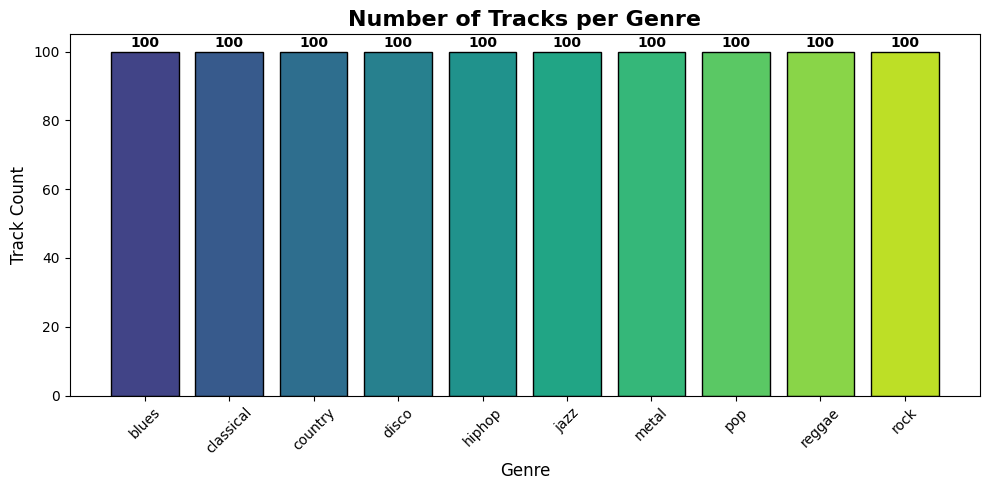

Total tracks: 1000


In [4]:
# ── 1.1  Class Distribution ────────────────────────────────────────────────────
genre_counts = {}
for genre in GENRES:
    gdir = STEMS_DIR / genre
    if gdir.exists():
        genre_counts[genre] = len([d for d in gdir.iterdir() if d.is_dir()])

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(genre_counts)))
bars = ax.bar(genre_counts.keys(), genre_counts.values(), color=colors, edgecolor='black')
ax.set_title('Number of Tracks per Genre', fontsize=16, fontweight='bold')
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Track Count', fontsize=12)
for bar, count in zip(bars, genre_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eda_class_distribution.png'), dpi=120)
plt.show()
print(f'Total tracks: {sum(genre_counts.values())}')

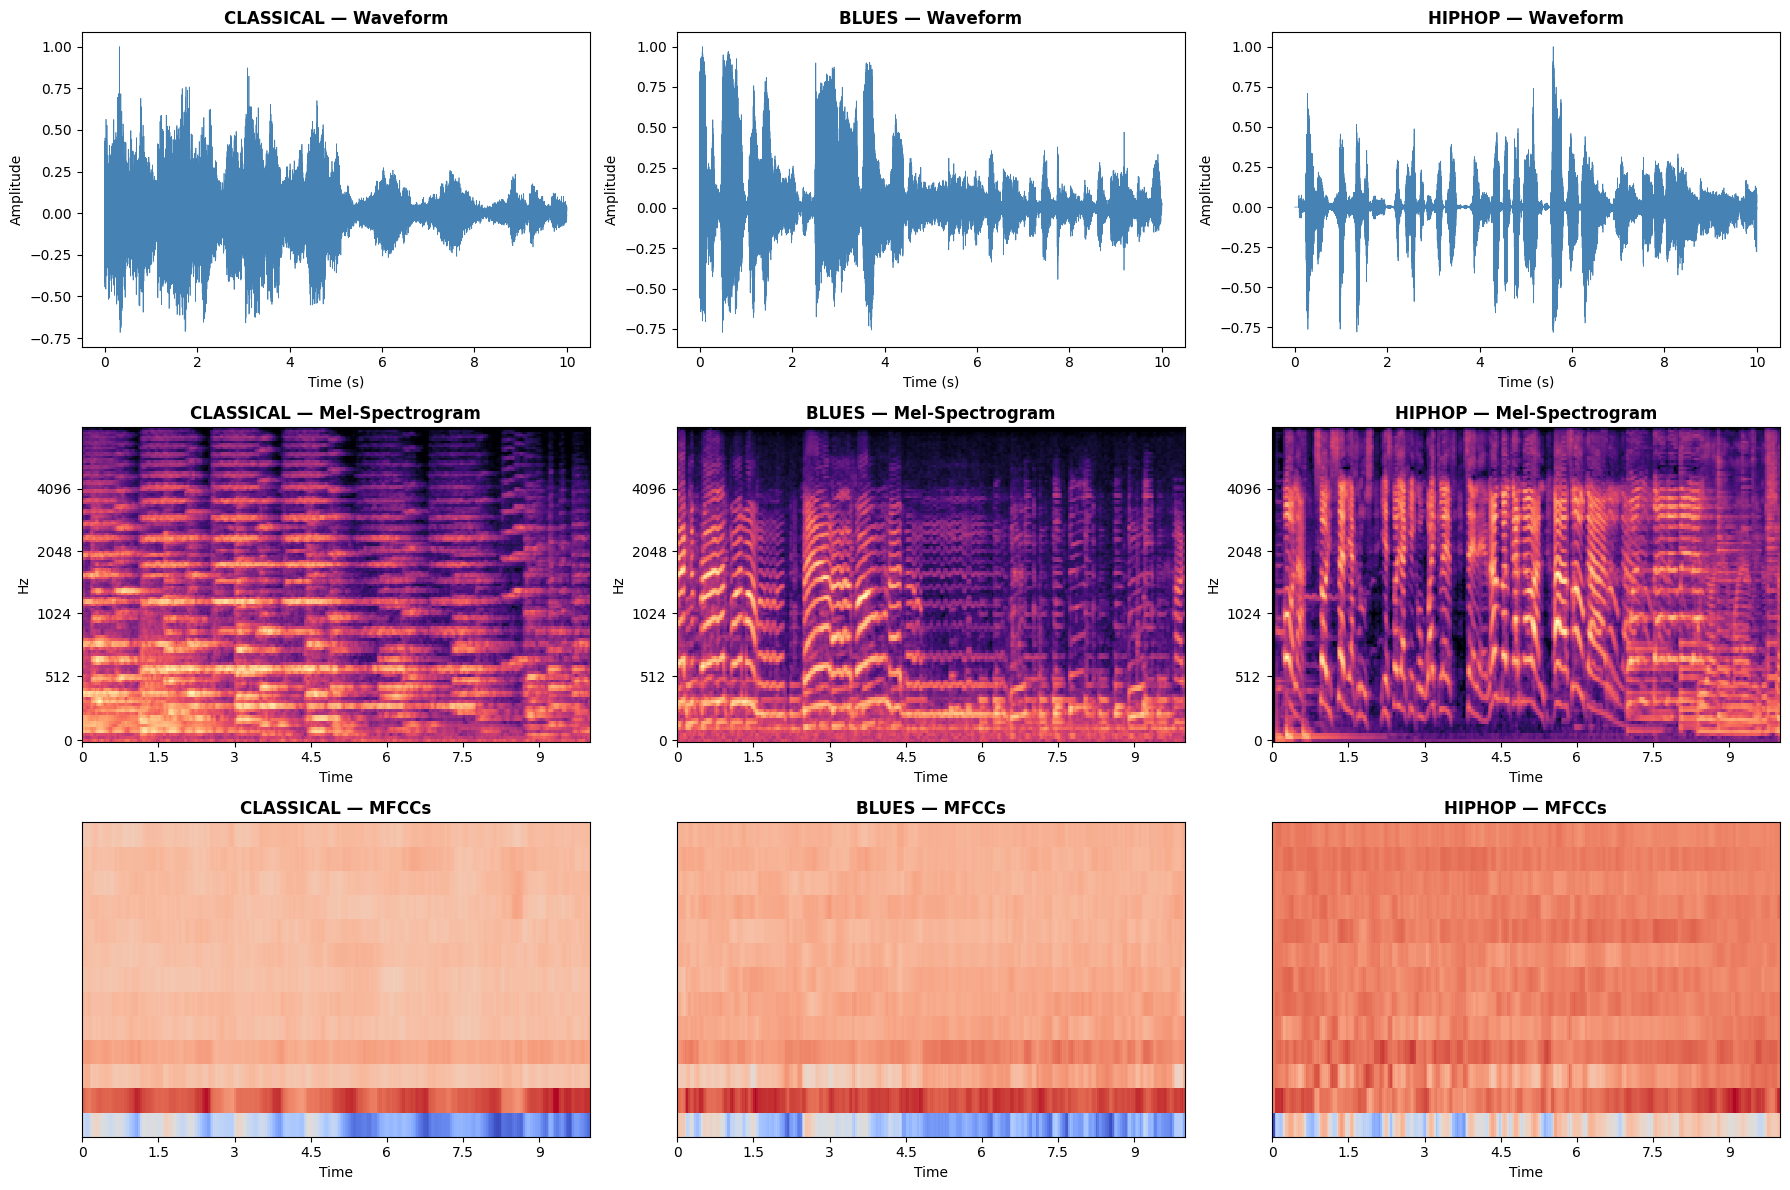

In [5]:
# ── 1.2  Waveform, Mel-Spectrogram & MFCC for sample tracks ───────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
sample_genres = random.sample(GENRES, 3)

for col, genre in enumerate(sample_genres):
    gdir = STEMS_DIR / genre
    track_dirs = [d for d in gdir.iterdir() if d.is_dir()]
    track = random.choice(track_dirs)
    stems = list(track.glob('*.wav'))
    # Mix all stems
    mixed = None
    for sp in stems:
        try:
            y_s, _ = librosa.load(str(sp), sr=SR, duration=CLIP_SEC)
            mixed = y_s if mixed is None else mixed[:len(y_s)] + y_s[:len(mixed)]
        except: pass
    if mixed is not None and np.max(np.abs(mixed)) > 0:
        mixed /= np.max(np.abs(mixed))

    # Row 0: Waveform
    axes[0, col].plot(np.linspace(0, len(mixed)/SR, len(mixed)), mixed, color='steelblue', linewidth=0.5)
    axes[0, col].set_title(f'{genre.upper()} — Waveform', fontweight='bold')
    axes[0, col].set_xlabel('Time (s)'); axes[0, col].set_ylabel('Amplitude')

    # Row 1: Mel-Spectrogram
    S = librosa.feature.melspectrogram(y=mixed, sr=SR, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=SR, x_axis='time', y_axis='mel', ax=axes[1, col], cmap='magma')
    axes[1, col].set_title(f'{genre.upper()} — Mel-Spectrogram', fontweight='bold')

    # Row 2: MFCC
    mfcc = librosa.feature.mfcc(y=mixed, sr=SR, n_mfcc=13)
    librosa.display.specshow(mfcc, sr=SR, x_axis='time', ax=axes[2, col], cmap='coolwarm')
    axes[2, col].set_title(f'{genre.upper()} — MFCCs', fontweight='bold')

plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eda_audio_features.png'), dpi=120)
plt.show()

Total mashup test files: 3020

First 5 mashup files:
  song0001.wav: 30.0s, samples=480003
  song0002.wav: 22.3s, samples=357402
  song0003.wav: 29.9s, samples=478517
  song0004.wav: 30.0s, samples=480003
  song0005.wav: 30.0s, samples=480003


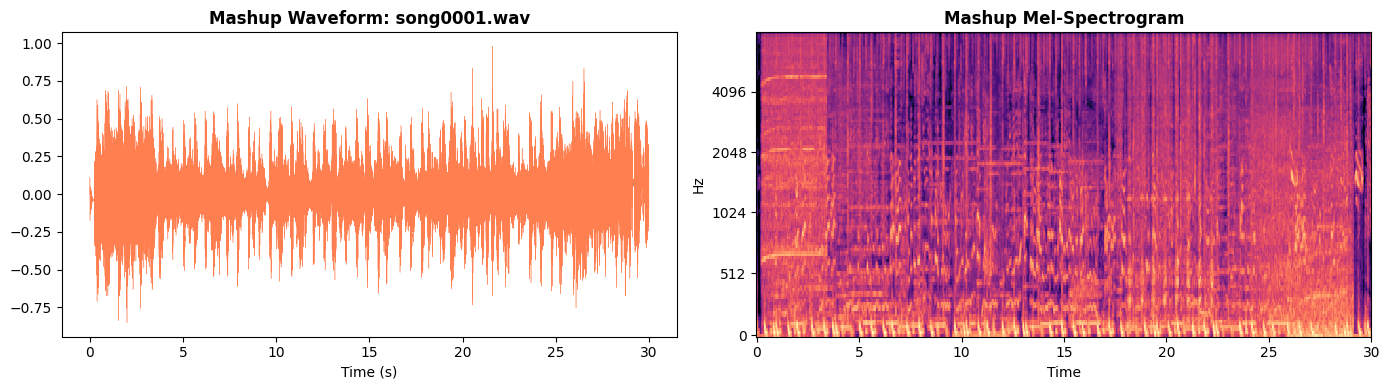

In [6]:
# ── 1.3  Mashup Audio Inspection ──────────────────────────────────────────────
mashup_files = sorted(MASHUP_DIR.glob('*.wav'))[:5]
print(f'Total mashup test files: {len(list(MASHUP_DIR.glob("*.wav")))}')
print(f'\nFirst 5 mashup files:')
for f in mashup_files:
    y, _ = librosa.load(str(f), sr=SR)
    dur = len(y) / SR
    print(f'  {f.name}: {dur:.1f}s, samples={len(y)}')

# Show spectrogram of a mashup
y_mash, _ = librosa.load(str(mashup_files[0]), sr=SR)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(np.linspace(0, len(y_mash)/SR, len(y_mash)), y_mash, color='coral', linewidth=0.3)
axes[0].set_title(f'Mashup Waveform: {mashup_files[0].name}', fontweight='bold')
axes[0].set_xlabel('Time (s)')
S_m = librosa.feature.melspectrogram(y=y_mash, sr=SR, n_mels=128)
librosa.display.specshow(librosa.power_to_db(S_m, ref=np.max), sr=SR, x_axis='time', y_axis='mel',
                         ax=axes[1], cmap='magma')
axes[1].set_title('Mashup Mel-Spectrogram', fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eda_mashup_spectrogram.png'), dpi=120)
plt.show()

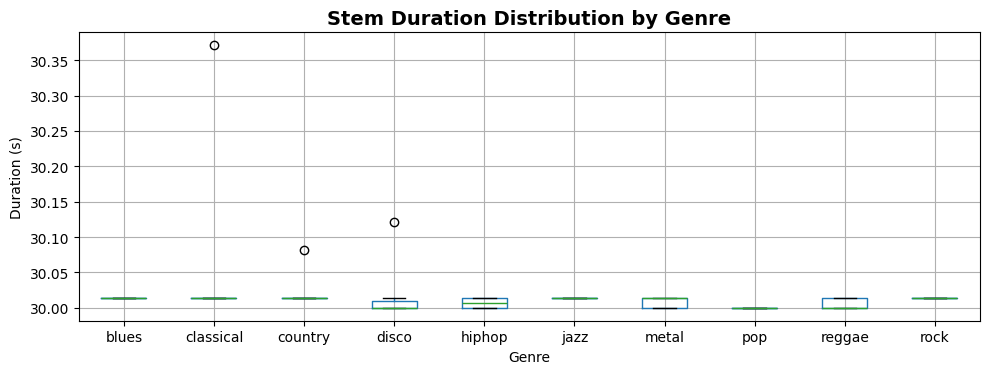

Mean duration: 30.0s | Std: 0.0s


In [7]:
# ── 1.4  Duration Statistics ───────────────────────────────────────────────────
durations = []
for genre in GENRES:
    gdir = STEMS_DIR / genre
    for track_dir in list(gdir.iterdir())[:10]:  # sample 10 per genre
        if track_dir.is_dir():
            stems = list(track_dir.glob('*.wav'))
            if stems:
                try:
                    y, _ = librosa.load(str(stems[0]), sr=SR)
                    durations.append({'genre': genre, 'duration': len(y) / SR})
                except: pass

dur_df = pd.DataFrame(durations)
fig, ax = plt.subplots(figsize=(10, 4))
dur_df.boxplot(column='duration', by='genre', ax=ax)
ax.set_title('Stem Duration Distribution by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre'); ax.set_ylabel('Duration (s)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eda_duration_distribution.png'), dpi=120)
plt.show()
print(f'Mean duration: {dur_df["duration"].mean():.1f}s | Std: {dur_df["duration"].std():.1f}s')

ESC-50 noise clips available: 2000


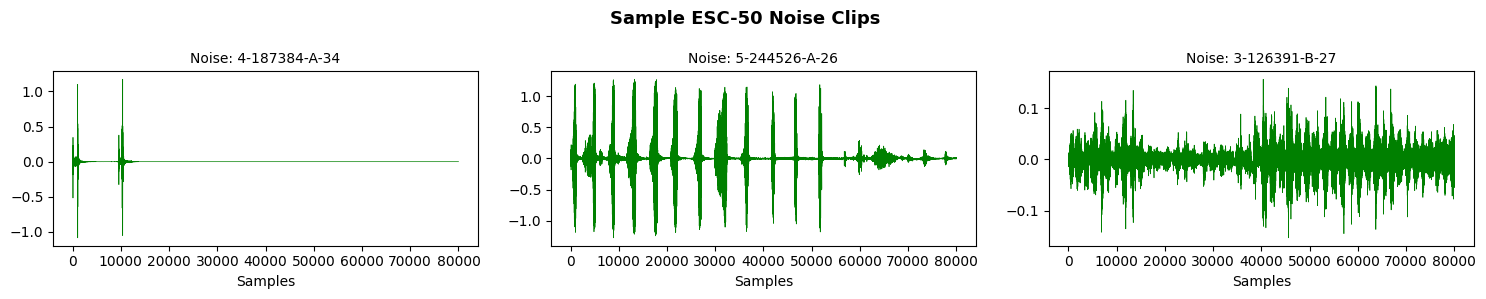

In [8]:
# ── 1.5  ESC-50 Noise Dataset Summary ─────────────────────────────────────────
if ESC50_DIR and ESC50_DIR.exists():
    esc_files = list(ESC50_DIR.rglob('*.wav'))
    print(f'ESC-50 noise clips available: {len(esc_files)}')
    # Show a few
    sample_noise = random.sample(esc_files, min(3, len(esc_files)))
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    for i, nf in enumerate(sample_noise):
        y_n, _ = librosa.load(str(nf), sr=SR, duration=5.0)
        axes[i].plot(y_n, color='green', linewidth=0.5)
        axes[i].set_title(f'Noise: {nf.stem}', fontsize=10)
        axes[i].set_xlabel('Samples')
    plt.suptitle('Sample ESC-50 Noise Clips', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / 'eda_noise_samples.png'), dpi=120)
    plt.show()
else:
    print('ESC-50 not found')

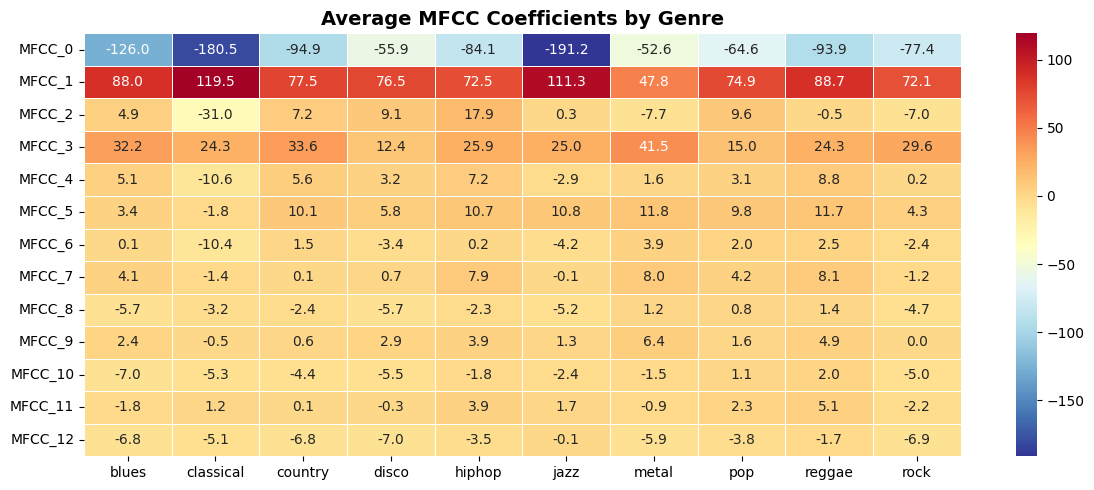

In [9]:
# ── 1.6  Average MFCC Profile per Genre ───────────────────────────────────────
mfcc_profiles = {}
for genre in GENRES:
    gdir = STEMS_DIR / genre
    tracks = [d for d in gdir.iterdir() if d.is_dir()][:5]
    genre_mfccs = []
    for track in tracks:
        stems = list(track.glob('*.wav'))
        mixed = None
        for sp in stems:
            try:
                y_s, _ = librosa.load(str(sp), sr=SR, duration=CLIP_SEC)
                mixed = y_s if mixed is None else mixed[:len(y_s)] + y_s[:len(mixed)]
            except: pass
        if mixed is not None:
            mfcc = librosa.feature.mfcc(y=mixed, sr=SR, n_mfcc=13)
            genre_mfccs.append(mfcc.mean(axis=1))
    if genre_mfccs:
        mfcc_profiles[genre] = np.mean(genre_mfccs, axis=0)

mfcc_df = pd.DataFrame(mfcc_profiles, index=[f'MFCC_{i}' for i in range(13)])
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(mfcc_df, annot=True, fmt='.1f', cmap='RdYlBu_r', ax=ax, linewidths=0.5)
ax.set_title('Average MFCC Coefficients by Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'eda_mfcc_heatmap.png'), dpi=120)
plt.show()

### EDA Summary
- **Balanced dataset**: ~100 tracks per genre (10 genres)
- **Stem-based**: Each track has drums, vocals, bass, other stems
- **Test mashups**: Stems from different songs mixed + noise added
- **Key challenge**: Train on individual tracks, test on cross-track mashups with noise
- **ESC-50**: Real-world environmental sounds used as noise augmentation

---
#  Section 2: Model 1 — CRNN (Built from Scratch)

A **Convolutional Recurrent Neural Network** combining:
- **2-layer CNN** to extract local spectral patterns from Mel-spectrograms
- **Bidirectional LSTM** to capture temporal structure
- **FC classifier** head

This model is built entirely from scratch in PyTorch (no pretrained weights).

In [10]:
# ── 2.0  W&B Login ────────────────────────────────────────────────────────────
import wandb

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=api_key)
    print('✅ W&B logged in via Kaggle secret')
except Exception as e:
    print(f'⚠️  Secret failed ({e}), trying env login...')
    wandb.login()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


⚠️  Secret failed (API key must be 40 characters long, yours was 86), trying env login...


wandb: Currently logged in as: 24f1001544-ankitkuamr (24f1001544-dl-genai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [11]:
# ── 2.1  Generate Synthetic Mashups for CRNN Training ─────────────────────────
import torchaudio

CRNN_SR = 22050
CRNN_DURATION = 30
CRNN_TARGET_LEN = CRNN_SR * CRNN_DURATION
SYNTH_DIR = OUT_DIR / 'synthetic_mashups' / 'train'

noise_files_esc = list(ESC50_DIR.rglob('*.wav')) if ESC50_DIR and ESC50_DIR.exists() else []
print(f'ESC-50 noise files: {len(noise_files_esc)}')

for genre in GENRES:
    genre_out = SYNTH_DIR / genre
    genre_out.mkdir(parents=True, exist_ok=True)
    song_folders = sorted((STEMS_DIR / genre).iterdir())
    song_folders = [s for s in song_folders if s.is_dir()]
    if len(song_folders) < 4:
        print(f'  ⚠️ {genre}: only {len(song_folders)} tracks, skipping')
        continue

    for i in range(100):
        chosen = random.sample(song_folders, 4)
        stem_types = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
        stems_audio = []
        for song, stype in zip(chosen, stem_types):
            sp = song / stype
            if not sp.exists():
                sp = song / stype.replace('other', 'others')
            if sp.exists():
                wf, sr_orig = torchaudio.load(str(sp))
                if sr_orig != CRNN_SR:
                    wf = torchaudio.transforms.Resample(sr_orig, CRNN_SR)(wf)
                if wf.shape[1] > CRNN_TARGET_LEN:
                    wf = wf[:, :CRNN_TARGET_LEN]
                elif wf.shape[1] < CRNN_TARGET_LEN:
                    wf = torch.nn.functional.pad(wf, (0, CRNN_TARGET_LEN - wf.shape[1]))
                stems_audio.append(wf)

        if len(stems_audio) == 4:
            mashup = torch.stack(stems_audio).sum(dim=0)
            mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)
            if noise_files_esc:
                nf = random.choice(noise_files_esc)
                noise, _ = torchaudio.load(str(nf))
                if noise.shape[1] > CRNN_TARGET_LEN:
                    noise = noise[:, :CRNN_TARGET_LEN]
                start = random.randint(0, CRNN_TARGET_LEN - noise.shape[1])
                mashup[:, start:start+noise.shape[1]] += noise * random.uniform(0.1, 0.4)
                mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)
            torchaudio.save(str(genre_out / f'mashup_{i:03d}.wav'), mashup, CRNN_SR)

    print(f'  {genre}: generated {len(list(genre_out.glob("*.wav")))} mashups')
print('✅ Synthetic mashup generation complete')

ESC-50 noise files: 2000
  blues: generated 100 mashups
  classical: generated 100 mashups
  country: generated 100 mashups
  disco: generated 100 mashups
  hiphop: generated 100 mashups
  jazz: generated 100 mashups
  metal: generated 100 mashups
  pop: generated 100 mashups
  reggae: generated 100 mashups
  rock: generated 100 mashups
✅ Synthetic mashup generation complete


In [12]:
# ── 2.2  Extract Mel-Spectrogram Features ─────────────────────────────────────
FEATURES_DIR = OUT_DIR / 'features' / 'train'

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=CRNN_SR, n_fft=2048, hop_length=512, n_mels=128
)
amp_to_db = torchaudio.transforms.AmplitudeToDB()

for wav_path in tqdm(list(SYNTH_DIR.rglob('*.wav')), desc='Extracting features'):
    rel = wav_path.relative_to(SYNTH_DIR)
    out_path = FEATURES_DIR / rel.with_suffix('.pt')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    wf, sr_f = torchaudio.load(str(wav_path))
    feat = amp_to_db(mel_transform(wf))
    torch.save(feat, str(out_path))

print(f'✅ Features saved to {FEATURES_DIR}')
print(f'   Total feature files: {len(list(FEATURES_DIR.rglob("*.pt")))}')

Extracting features:   0%|          | 0/1000 [00:00<?, ?it/s]

✅ Features saved to /kaggle/working/features/train
   Total feature files: 1000


In [13]:
# ── 2.3  CRNN Dataset & Model ─────────────────────────────────────────────────
class PrecomputedFeatureDataset(Dataset):
    def __init__(self, features_dir, max_time=1292):
        self.files = sorted(glob.glob(os.path.join(str(features_dir), '**', '*.pt'), recursive=True))
        self.genres = GENRES
        self.genre_to_idx = GENRE2ID
        self.max_time = max_time

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        genre = Path(fp).parent.name
        label = self.genre_to_idx[genre]
        feature = torch.load(fp)  # shape: (C, 128, T)
        if feature.shape[0] > 1:
            feature = feature.mean(dim=0, keepdim=True)  # stereo → mono

        # Pad or trim time axis
        if feature.shape[-1] < self.max_time:
            feature = F.pad(feature, (0, self.max_time - feature.shape[-1]))
        else:
            feature = feature[..., :self.max_time]
        # Random time-shift augmentation
       

        return feature, label


class CRNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # CNN Backbone: (B, 1, 128, T) → (B, 64, 32, T/4)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Dropout2d(0.25),                         # ← ADD THIS
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Dropout2d(0.25),                         # ← ADD THIS
        )
        # RNN: input_size = 64 * 32 = 2048
        self.lstm = nn.LSTM(
            input_size=2048, hidden_size=64,
            num_layers=1, bidirectional=True, batch_first=True
        )
        self.dropout = nn.Dropout(0.4)
        # Classifier: bidirectional → hidden*2 = 128
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (B, 1, 128, T)
        x = self.cnn(x)                          # (B, 64, 32, T/4)
        b, c, f, t = x.shape
        x = x.permute(0, 3, 1, 2).reshape(b, t, c * f)  # (B, T/4, 2048)
        x, _ = self.lstm(x)                       # (B, T/4, 128)
        x = torch.max(x, dim=1).values            # (B, 128) global max pool
        logits = self.fc(self.dropout(x))
                     # (B, 10)
        return logits


crnn_model = CRNN(num_classes=10).to(DEVICE)
total_p = sum(p.numel() for p in crnn_model.parameters())
print(f'✅ CRNN model created | Total params: {total_p:,}')
print(crnn_model)

✅ CRNN model created | Total params: 1,102,666
CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
  )
  (lstm): LSTM(2048, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


In [14]:
# ── 2.4  CRNN Training ────────────────────────────────────────────────────────
crnn_ds = PrecomputedFeatureDataset(FEATURES_DIR)
n_val = int(len(crnn_ds) * 0.15)
n_train = len(crnn_ds) - n_val
crnn_train_ds, crnn_val_ds = torch.utils.data.random_split(crnn_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(SEED))

# Using num_workers=0 here for stability on Kaggle
crnn_train_loader = DataLoader(crnn_train_ds, batch_size=16, shuffle=True, num_workers=0)
crnn_val_loader   = DataLoader(crnn_val_ds,   batch_size=16, shuffle=False, num_workers=0)

crnn_optimizer = torch.optim.Adam(crnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
crnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(crnn_optimizer, T_max=15)
crnn_criterion = nn.CrossEntropyLoss()

CRNN_EPOCHS = 15

run_crnn = wandb.init(
    project='24f1001544-t12026', name='crnn-from-scratch',
    config={'model': 'CRNN', 'epochs': CRNN_EPOCHS, 'lr': 1e-3, 'batch_size': 16},
    settings=wandb.Settings(start_method='thread'), reinit=True,
)

crnn_history = []
best_crnn_f1 = 0.0

for epoch in range(1, CRNN_EPOCHS + 1):
    crnn_model.train()
    tr_loss, tr_preds, tr_labels = 0.0, [], []
    for feats, labels in tqdm(crnn_train_loader, desc=f'CRNN Ep {epoch:02d}', leave=False):
        feats, labels = feats.to(DEVICE), labels.to(DEVICE)
        
        # ─── DATA AUGMENTATION ON THE FLY (Only during training) ───
        # Random time-shift
        if random.random() > 0.5:
            shift = random.randint(0, feats.shape[-1] // 8)
            feats = torch.roll(feats, shifts=shift, dims=-1)
        # Random amplitude scaling
        if random.random() > 0.5:
            feats = feats * random.uniform(0.7, 1.3)
        # ───────────────────────────────────────────────────────────
        
        out = crnn_model(feats)
        loss = crnn_criterion(out, labels)
        crnn_optimizer.zero_grad()
        loss.backward()
        crnn_optimizer.step()
        tr_loss += loss.item()
        tr_preds += out.argmax(-1).cpu().tolist()
        tr_labels += labels.cpu().tolist()
    crnn_scheduler.step()
    tr_f1 = f1_score(tr_labels, tr_preds, average='macro')

    crnn_model.eval()
    va_preds, va_labels = [], []
    with torch.no_grad():
        for feats, labels in crnn_val_loader:
            feats, labels = feats.to(DEVICE), labels.to(DEVICE)
            out = crnn_model(feats)
            va_preds += out.argmax(-1).cpu().tolist()
            va_labels += labels.cpu().tolist()
    va_f1 = f1_score(va_labels, va_preds, average='macro')
    va_acc = accuracy_score(va_labels, va_preds)

    log = {'epoch': epoch, 'train_loss': tr_loss/len(crnn_train_loader),
           'train_f1': tr_f1, 'val_f1': va_f1, 'val_acc': va_acc}
    crnn_history.append(log)
    wandb.log(log)

    star = '🏆' if va_f1 > best_crnn_f1 else ''
    if va_f1 > best_crnn_f1:
        best_crnn_f1 = va_f1
        torch.save(crnn_model.state_dict(), str(OUT_DIR / 'crnn_best.pt'))
    print(f'Ep {epoch:02d} | tr_f1={tr_f1:.4f} | va_f1={va_f1:.4f} va_acc={va_acc:.4f} {star}')

print(f'\n✅ Best CRNN Val F1: {best_crnn_f1:.4f}')


wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: setting up run hub4zskt
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260327_101811-hub4zskt
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run crnn-from-scratch
wandb: ⭐️ View project at https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026
wandb: 🚀 View run at https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026/runs/hub4zskt


CRNN Ep 01:   0%|          | 0/54 [00:00<?, ?it/s]

Ep 01 | tr_f1=0.1771 | va_f1=0.2505 va_acc=0.3400 🏆


CRNN Ep 02:   0%|          | 0/54 [00:00<?, ?it/s]

Ep 02 | tr_f1=0.2701 | va_f1=0.2486 va_acc=0.3467 


...

Ep 13 | tr_f1=0.5086 | va_f1=0.5914 va_acc=0.6067 🏆


CRNN Ep 14:   0%|          | 0/54 [00:00<?, ?it/s]

Ep 14 | tr_f1=0.4848 | va_f1=0.5678 va_acc=0.6000 


CRNN Ep 15:   0%|          | 0/54 [00:00<?, ?it/s]

Ep 15 | tr_f1=0.5130 | va_f1=0.5563 va_acc=0.5800 

✅ Best CRNN Val F1: 0.5914


=== CRNN Classification Report ===
              precision    recall  f1-score   support

       blues     0.4615    0.7059    0.5581        17
   classical     0.6111    0.7333    0.6667        15
     country     0.7500    0.6429    0.6923        14
       disco     0.5000    0.3750    0.4286         8
      hiphop     0.8333    0.5882    0.6897        17
        jazz     0.6667    0.2727    0.3871        22
       metal     0.6818    0.9375    0.7895        16
         pop     0.5909    1.0000    0.7429        13
      reggae     0.8571    0.4000    0.5455        15
        rock     0.3750    0.4615    0.4138        13

    accuracy                         0.6067       150
   macro avg     0.6328    0.6117    0.5914       150
weighted avg     0.6445    0.6067    0.5913       150



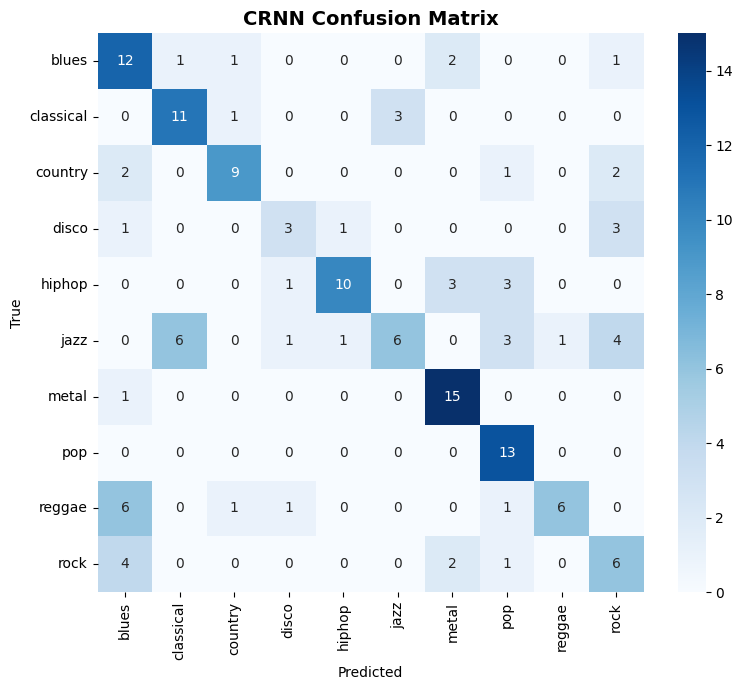

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb: crnn_best_acc ▁
wandb:  crnn_best_f1 ▁
wandb:         epoch ▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
wandb:      train_f1 ▁▃▃▄▅▅▅▆▆▇▇▇█▇█
wandb:    train_loss █▇▆▅▄▃▃▃▂▂▂▁▁▁▁
wandb:       val_acc ▁▁▄▄▄▄▅▇▇▆▇███▇
wandb:        val_f1 ▁▁▄▄▄▄▅▇▇▆▇▇██▇
wandb: 
wandb: Run summary:
wandb: crnn_best_acc 0.60667
wandb:  crnn_best_f1 0.5914
wandb:         epoch 15
wandb:      train_f1 0.513
wandb:    train_loss 1.38195
wandb:       val_acc 0.58
wandb:        val_f1 0.55629
wandb: 
wandb: 🚀 View run crnn-from-scratch at: https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026/runs/hub4zskt
wandb: ⭐️ View project at: https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026
wandb: Synced 5 W&B file(s), 1 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260327_101811-hub4zskt/logs


✅ CRNN Run finished | F1=0.5914 | Acc=0.6067


In [15]:
# ── 2.5  CRNN Final Evaluation ─────────────────────────────────────────────────
crnn_model.load_state_dict(torch.load(str(OUT_DIR / 'crnn_best.pt'), map_location=DEVICE))
crnn_model.eval()

crnn_all_preds, crnn_all_labels = [], []
with torch.no_grad():
    for feats, labels in crnn_val_loader:
        feats = feats.to(DEVICE)
        out = crnn_model(feats)
        crnn_all_preds += out.argmax(-1).cpu().tolist()
        crnn_all_labels += labels.tolist()

crnn_final_f1 = f1_score(crnn_all_labels, crnn_all_preds, average='macro')
crnn_final_acc = accuracy_score(crnn_all_labels, crnn_all_preds)

print('=== CRNN Classification Report ===')
print(classification_report(crnn_all_labels, crnn_all_preds, target_names=GENRES, digits=4))

# Confusion matrix
cm = confusion_matrix(crnn_all_labels, crnn_all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=GENRES, yticklabels=GENRES, ax=ax)
ax.set_title('CRNN Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'crnn_confusion_matrix.png'), dpi=120)
plt.show()

wandb.log({'crnn_best_f1': crnn_final_f1, 'crnn_best_acc': crnn_final_acc,
           'crnn_confusion': wandb.Image(str(OUT_DIR / 'crnn_confusion_matrix.png'))})
wandb.finish()
print(f'✅ CRNN Run finished | F1={crnn_final_f1:.4f} | Acc={crnn_final_acc:.4f}')

---
#  Section 3: Model 2 — Pretrained Audio Spectrogram Transformer (AST v3)

The **Audio Spectrogram Transformer** (MIT/ast-finetuned-audioset) is a Vision Transformer
pretrained on AudioSet. We fine-tune it with:
- **Cross-track stem mixing** (70% prob) — each stem from a different track in same genre
- **Tempo augmentation** (±12%) — mimics tempo sync in mashup creation
- **Aggressive noise** (SNR -5 to 12 dB) — ESC-50 environmental sounds
- **Mixup** (α=0.3) — blend pairs of spectrograms with soft labels
- **3-phase gradual unfreezing** — head → top4 blocks → full encoder
- **14-pass TTA** (7 clean + 7 noise) with temperature scaling
- **Per-class threshold optimization**

In [16]:
# ── 3.0  AST Config ───────────────────────────────────────────────────────────
MODEL_NAME     = 'MIT/ast-finetuned-audioset-10-10-0.4593'
BATCH_SIZE     = 8
GRAD_ACCUM     = 4          # effective batch = 32
EPOCHS         = 20
LR             = 1e-4
WARMUP_RATIO   = 0.1
VAL_SPLIT      = 0.15
MIXUP_ALPHA    = 0.3
TEMP_SCALE     = 1.5        # soften predictions at inference

# Cross-track stem mixing (KEY FIX)
CROSS_MIX_PROB = 0.7
STEM_NAMES     = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav',
                  'drums.wav', 'vocals.wav', 'bass.wav', 'others.wav']

# Noise aug
SNR_MIN, SNR_MAX = -5, 12
NOISE_PROB       = 0.85

# Tempo augmentation
TEMPO_AUG_PROB = 0.5
TEMPO_RATE_MIN = 0.88
TEMPO_RATE_MAX = 1.12

# Offsets
OFFSETS     = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0]
TTA_OFFSETS = [0.0, 3.0, 7.0, 10.0, 15.0, 20.0, 25.0]

# 3-phase unfreeze
UNFREEZE_TOP_EPOCH  = 2
UNFREEZE_FULL_EPOCH = 8

CHECKPOINT  = str(OUT_DIR / 'ast_v3_best.pt')

print(f'Cross-mix prob: {CROSS_MIX_PROB} | NOISE_PROB: {NOISE_PROB} | '
      f'SNR: [{SNR_MIN},{SNR_MAX}]dB | TEMPO_AUG: [{TEMPO_RATE_MIN},{TEMPO_RATE_MAX}]')

Cross-mix prob: 0.7 | NOISE_PROB: 0.85 | SNR: [-5,12]dB | TEMPO_AUG: [0.88,1.12]


In [17]:
# ── 3.1  W&B for AST ──────────────────────────────────────────────────────────
run_ast = wandb.init(
    project='24f1001544-t12026', name='ast-v3-cross-stem-mix',
    config={
        'model': MODEL_NAME, 'epochs': EPOCHS,
        'batch_size': BATCH_SIZE, 'grad_accum': GRAD_ACCUM,
        'lr': LR, 'clip_sec': CLIP_SEC,
        'cross_mix_prob': CROSS_MIX_PROB,
        'snr_range': f'{SNR_MIN}-{SNR_MAX}dB',
        'noise_prob': NOISE_PROB,
        'tempo_aug': f'{TEMPO_RATE_MIN}-{TEMPO_RATE_MAX}',
        'mixup_alpha': MIXUP_ALPHA,
        'temp_scale': TEMP_SCALE,
    },
    settings=wandb.Settings(start_method='thread'), reinit=True,
)
print(f'✅ W&B run: {run_ast.name}')

wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260327_102005-ahu6bkvp
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run ast-v3-cross-stem-mix
wandb: ⭐️ View project at https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026
wandb: 🚀 View run at https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026/runs/ahu6bkvp


✅ W&B run: ast-v3-cross-stem-mix


In [18]:
# ── 3.2  Load AST Model ───────────────────────────────────────────────────────
feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_NAME)
ast_model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME, num_labels=10, ignore_mismatched_sizes=True,
    label2id=GENRE2ID, id2label=ID2GENRE,
)
ast_model = ast_model.to(DEVICE)
total_ast = sum(p.numel() for p in ast_model.parameters())
print(f'✅ AST loaded | Total: {total_ast:,}')

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ AST loaded | Total: 86,196,490


In [19]:
# ── 3.3  ESC-50 Noise Pool ────────────────────────────────────────────────────
noise_pool = []
if ESC50_DIR and ESC50_DIR.exists():
    esc50_files = list(ESC50_DIR.rglob('*.wav'))
    print(f'Loading {len(esc50_files)} ESC-50 clips...')
    for fp in tqdm(esc50_files, desc='ESC-50'):
        try:
            y, _ = librosa.load(str(fp), sr=SR, mono=True)
            if len(y) > 1000:
                noise_pool.append(y)
        except Exception:
            pass
    print(f'✅ {len(noise_pool)} noise clips loaded')
else:
    print('⚠️  ESC-50 not found — training WITHOUT noise augmentation')

Loading 2000 ESC-50 clips...


ESC-50:   0%|          | 0/2000 [00:00<?, ?it/s]

✅ 2000 noise clips loaded


In [20]:
# ── 3.4  Build Genre Track Index ──────────────────────────────────────────────
genre_tracks = defaultdict(list)
for genre in GENRES:
    gdir = STEMS_DIR / genre
    if not gdir.exists(): continue
    for track_dir in sorted(gdir.iterdir()):
        if track_dir.is_dir():
            genre_tracks[GENRE2ID[genre]].append(track_dir)

for g, tracks in genre_tracks.items():
    print(f'  {GENRES[g]:12s}: {len(tracks)} tracks')

all_samples = []
for genre_id, tracks in genre_tracks.items():
    for track_dir in tracks:
        for off in OFFSETS:
            all_samples.append((track_dir, off, genre_id))

random.shuffle(all_samples)
print(f'\nTotal samples: {len(all_samples)}')

labels_all = [s[2] for s in all_samples]
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
tr_idx, val_idx = next(sss.split(all_samples, labels_all))

train_samples = [all_samples[i] for i in tr_idx]
val_samples   = [all_samples[i] for i in val_idx]
print(f'Train: {len(train_samples)} | Val: {len(val_samples)}')

  blues       : 100 tracks
  classical   : 100 tracks
  country     : 100 tracks
  disco       : 100 tracks
  hiphop      : 100 tracks
  jazz        : 100 tracks
  metal       : 100 tracks
  pop         : 100 tracks
  reggae      : 100 tracks
  rock        : 100 tracks

Total samples: 6000
Train: 5100 | Val: 900


In [21]:
# ── 3.5  Audio Utilities ──────────────────────────────────────────────────────
def load_stem(stem_path, sr=SR, duration=CLIP_SEC, offset=0.0):
    try:
        y, _ = librosa.load(str(stem_path), sr=sr, mono=True, duration=duration, offset=offset)
        return y.astype(np.float32)
    except Exception:
        return None

def mix_stems_same_track(track_dir, sr=SR, duration=CLIP_SEC, offset=0.0):
    stems = list(Path(track_dir).glob('*.wav'))
    mixed = None
    for sp in stems:
        y = load_stem(sp, sr, duration, offset)
        if y is not None:
            mixed = y if mixed is None else mixed[:len(y)] + y[:len(mixed)]
    if mixed is not None and np.max(np.abs(mixed)) > 0:
        mixed /= np.max(np.abs(mixed))
    return mixed

def mix_stems_cross_track(primary_dir, genre_id, sr=SR, duration=CLIP_SEC, offset=0.0):
    available_tracks = genre_tracks[genre_id]
    if len(available_tracks) < 2:
        return mix_stems_same_track(primary_dir, sr, duration, offset)
    stem_files = [f.name for f in Path(primary_dir).glob('*.wav')]
    if not stem_files: return None
    mixed = None
    for stem_name in stem_files:
        source_track = random.choice(available_tracks)
        stem_path = source_track / stem_name
        if not stem_path.exists():
            stem_path = primary_dir / stem_name
        y = load_stem(stem_path, sr, duration, offset)
        if y is not None:
            mixed = y if mixed is None else mixed[:len(y)] + y[:len(mixed)]
    if mixed is not None and np.max(np.abs(mixed)) > 0:
        mixed /= np.max(np.abs(mixed))
    return mixed

def add_noise_snr(signal, noise, snr_db):
    n  = np.tile(noise, int(np.ceil(len(signal)/len(noise))))[:len(signal)]
    ps = np.mean(signal**2) + 1e-9
    pn = np.mean(n**2) + 1e-9
    scale = np.sqrt(ps / pn / (10**(snr_db/10)))
    out = signal + scale * n
    if np.max(np.abs(out)) > 0:
        out /= np.max(np.abs(out))
    return out.astype(np.float32)

def apply_tempo_aug(y, sr=SR):
    rate = random.uniform(TEMPO_RATE_MIN, TEMPO_RATE_MAX)
    try: return librosa.effects.time_stretch(y, rate=rate)
    except: return y

In [22]:
# ── 3.6  AST Dataset ──────────────────────────────────────────────────────────
def spec_augment(spec, freq_mask_param=24, time_mask_param=80, n_masks=2):
    spec = spec.clone()
    T, F = spec.shape
    for _ in range(n_masks):
        f  = random.randint(1, freq_mask_param)
        f0 = random.randint(0, max(F - f, 0))
        spec[:, f0:f0 + f] = 0.0
    for _ in range(n_masks):
        t  = random.randint(1, time_mask_param)
        t0 = random.randint(0, max(T - t, 0))
        spec[t0:t0 + t, :] = 0.0
    return spec

class GenreDataset(Dataset):
    def __init__(self, samples, feature_extractor, noise_pool=None, augment=True, cross_mix=True):
        self.samples = samples
        self.feature_extractor = feature_extractor
        self.noise_pool = noise_pool or []
        self.augment = augment
        self.cross_mix = cross_mix

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        track_dir, offset, label = self.samples[idx]
        use_cross = self.augment and self.cross_mix and random.random() < CROSS_MIX_PROB
        y = mix_stems_cross_track(track_dir, label, offset=offset) if use_cross else mix_stems_same_track(track_dir, offset=offset)
        if y is None: y = np.zeros(CLIP_SAMPLES, dtype=np.float32)
        if self.augment and random.random() < TEMPO_AUG_PROB: y = apply_tempo_aug(y)
        if len(y) < CLIP_SAMPLES: y = np.pad(y, (0, CLIP_SAMPLES - len(y)), mode='wrap')
        else: y = y[:CLIP_SAMPLES]
        if self.augment and self.noise_pool and random.random() < NOISE_PROB:
            y = add_noise_snr(y, random.choice(self.noise_pool), random.uniform(SNR_MIN, SNR_MAX))
        if self.augment and random.random() > 0.5: y = np.roll(y, random.randint(0, CLIP_SAMPLES // 4))
        if self.augment and random.random() > 0.4:
            y = y * random.uniform(0.4, 1.0)
            if np.max(np.abs(y)) > 0: y = y / np.max(np.abs(y))
        inputs = self.feature_extractor(y.astype(np.float32), sampling_rate=SR, return_tensors='pt')
        x = inputs['input_values'].squeeze(0)
        if self.augment: x = spec_augment(x)
        return {'input_values': x, 'labels': torch.tensor(label, dtype=torch.long)}

In [23]:
# ── 3.7  DataLoaders + Mixup ──────────────────────────────────────────────────
train_ds = GenreDataset(train_samples, feature_extractor, noise_pool, augment=True, cross_mix=True)
val_ds   = GenreDataset(val_samples, feature_extractor, noise_pool, augment=False, cross_mix=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

v1_f1 = [0.9890, 0.9890, 0.9556, 0.9773, 0.9091, 0.9888, 0.9149, 0.9362, 0.9655, 0.8636]
raw_w  = [1.0 / f for f in v1_f1]
mean_w = sum(raw_w) / len(raw_w)
class_weights = torch.tensor([w / mean_w for w in raw_w], dtype=torch.float32).to(DEVICE)

print(f'Train batches : {len(train_loader)} | Val batches : {len(val_loader)}')
print(f'Class weights : {[round(float(w), 3) for w in class_weights]}')

def mixup_batch(x, y_one_hot, alpha=MIXUP_ALPHA):
    if alpha <= 0: return x, y_one_hot
    lam = max(float(np.random.beta(alpha, alpha)), 1 - float(np.random.beta(alpha, alpha)))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[idx], lam * y_one_hot + (1-lam) * y_one_hot[idx]

Train batches : 638 | Val batches : 113
Class weights : [0.958, 0.958, 0.991, 0.969, 1.042, 0.958, 1.035, 1.012, 0.981, 1.097]


In [24]:
# ── 3.8  3-Phase Unfreezing + Training Loop ──────────────────────────────────
def freeze_all_except_classifier(m):
    for n, p in m.named_parameters(): p.requires_grad = 'classifier' in n

def unfreeze_top_blocks(m, n_blocks=4):
    total_layers = len(m.audio_spectrogram_transformer.encoder.layer)
    for name, p in m.named_parameters():
        if 'classifier' in name: p.requires_grad = True
        elif 'encoder.layer' in name:
            try: idx = int(name.split('encoder.layer.')[1].split('.')[0]); p.requires_grad = (idx >= total_layers - n_blocks)
            except: p.requires_grad = False
        else: p.requires_grad = False

def unfreeze_all(m):
    for p in m.parameters(): p.requires_grad = True

def make_optimizer(m):
    enc = [p for n, p in m.named_parameters() if p.requires_grad and 'classifier' not in n]
    hd  = [p for n, p in m.named_parameters() if p.requires_grad and 'classifier' in n]
    groups = []
    if enc: groups.append({'params': enc, 'lr': LR * 0.1})
    if hd:  groups.append({'params': hd,  'lr': LR})
    return torch.optim.AdamW(groups, weight_decay=0.01)

freeze_all_except_classifier(ast_model)
optimizer   = make_optimizer(ast_model)
total_steps = EPOCHS * len(train_loader) // GRAD_ACCUM
scheduler   = get_cosine_schedule_with_warmup(optimizer, int(WARMUP_RATIO * total_steps), total_steps)
criterion   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
print(f'Phase 1: head-only | Trainable: {sum(p.numel() for p in ast_model.parameters() if p.requires_grad):,}')

Phase 1: head-only | Trainable: 9,226


In [25]:
# ── 3.9  Training ─────────────────────────────────────────────────────────────
best_val_f1 = 0.0
history     = []
START_EPOCH = 1

if Path(CHECKPOINT).exists():
    ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
    ast_model.load_state_dict(ckpt['model_state_dict'])
    best_val_f1 = ckpt['best_val_f1']
    history     = ckpt.get('history', [])
    START_EPOCH = ckpt['epoch'] + 1
    print(f'Resuming from epoch {START_EPOCH} | Best val F1: {best_val_f1:.4f}')
    if START_EPOCH > UNFREEZE_FULL_EPOCH: unfreeze_all(ast_model); optimizer = make_optimizer(ast_model)
    elif START_EPOCH > UNFREEZE_TOP_EPOCH: unfreeze_top_blocks(ast_model, 4); optimizer = make_optimizer(ast_model)
    remaining = max(1, (EPOCHS - START_EPOCH + 1)) * len(train_loader) // GRAD_ACCUM
    scheduler = get_cosine_schedule_with_warmup(optimizer, 0, remaining)
else:
    print('🚀 Starting fresh training...')

for epoch in range(START_EPOCH, EPOCHS + 1):
    if epoch == UNFREEZE_TOP_EPOCH:
        print(f'  ↳ Ep {epoch}: Unfreezing top 4 blocks')
        unfreeze_top_blocks(ast_model, 4); optimizer = make_optimizer(ast_model)
        scheduler = get_cosine_schedule_with_warmup(optimizer, 0, (EPOCHS-epoch+1)*len(train_loader)//GRAD_ACCUM)
    elif epoch == UNFREEZE_FULL_EPOCH:
        print(f'  ↳ Ep {epoch}: Unfreezing FULL encoder')
        unfreeze_all(ast_model); optimizer = make_optimizer(ast_model)
        scheduler = get_cosine_schedule_with_warmup(optimizer, 0, (EPOCHS-epoch+1)*len(train_loader)//GRAD_ACCUM)

    ast_model.train()
    tr_loss, tr_preds, tr_lbls = 0.0, [], []
    optimizer.zero_grad()
    for step, batch in enumerate(tqdm(train_loader, desc=f'AST Ep {epoch:02d}', leave=False)):
        iv, labels = batch['input_values'].to(DEVICE), batch['labels'].to(DEVICE)
        y_oh = F.one_hot(labels, 10).float()
        iv_m, y_m = mixup_batch(iv, y_oh)
        out = ast_model(input_values=iv_m)
        loss = -(y_m * F.log_softmax(out.logits, -1)).sum(-1).mean() / GRAD_ACCUM
        loss.backward()
        if (step+1) % GRAD_ACCUM == 0 or (step+1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(ast_model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
        tr_loss += loss.item() * GRAD_ACCUM
        tr_preds += out.logits.argmax(-1).cpu().tolist()
        tr_lbls  += labels.cpu().tolist()
    tr_f1 = f1_score(tr_lbls, tr_preds, average='macro')

    ast_model.eval()
    va_loss, va_preds, va_lbls = 0.0, [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'AST Val {epoch:02d}', leave=False):
            iv, lb = batch['input_values'].to(DEVICE), batch['labels'].to(DEVICE)
            out = ast_model(input_values=iv)
            va_loss += criterion(out.logits, lb).item()
            va_preds += out.logits.argmax(-1).cpu().tolist()
            va_lbls  += lb.cpu().tolist()
    va_f1 = f1_score(va_lbls, va_preds, average='macro')

    log = {'epoch': epoch, 'train_loss': tr_loss/len(train_loader),
           'val_loss': va_loss/len(val_loader), 'train_f1': tr_f1, 'val_f1': va_f1,
           'lr': optimizer.param_groups[-1]['lr']}
    history.append(log); wandb.log(log)
    star = '🏆' if va_f1 > best_val_f1 else ''
    print(f'Ep {epoch:02d} | tr_f1={tr_f1:.4f} | va_f1={va_f1:.4f} {star}')
    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        torch.save({'epoch': epoch, 'model_state_dict': ast_model.state_dict(),
                     'optimizer_state_dict': optimizer.state_dict(),
                     'scheduler_state_dict': scheduler.state_dict(),
                     'best_val_f1': best_val_f1, 'history': history}, CHECKPOINT)

print(f'\n✅ Best AST Val Macro F1: {best_val_f1:.4f}')

🚀 Starting fresh training...


AST Ep 01:   0%|          | 0/638 [00:00<?, ?it/s]

AST Val 01:   0%|          | 0/113 [00:00<?, ?it/s]

Ep 01 | tr_f1=0.0853 | va_f1=0.1618 🏆
  ↳ Ep 2: Unfreezing top 4 blocks


AST Ep 02:   0%|          | 0/638 [00:00<?, ?it/s]

...

Ep 19 | tr_f1=0.7131 | va_f1=0.9420 


AST Ep 20:   0%|          | 0/638 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2ff857f740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7f2ff857f740>^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
^^^    ^self._shutdown_workers()^^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
^    ^if w.is_alive():
Exception

AST Val 20:   0%|          | 0/113 [00:00<?, ?it/s]

Ep 20 | tr_f1=0.7041 | va_f1=0.9409 

✅ Best AST Val Macro F1: 0.9432


In [26]:
# ── 3.10  AST Eval + Threshold ────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
ast_model.load_state_dict(ckpt['model_state_dict'])
ast_model.eval()

all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc='AST Final eval'):
        iv = batch['input_values'].to(DEVICE)
        lbl = batch['labels'].to(DEVICE)
        probs = torch.softmax(ast_model(input_values=iv).logits / TEMP_SCALE, -1).cpu().numpy()
        all_probs.append(probs)
        all_preds += probs.argmax(-1).tolist()
        all_labels += lbl.cpu().tolist()

all_probs  = np.vstack(all_probs)
all_labels = np.array(all_labels)
print("=== AST Val Report (T-scaled argmax) ===")
print(classification_report(all_labels, all_preds, target_names=GENRES, digits=4))

# Per-class threshold search
from sklearn.metrics import f1_score as sk_f1
thresholds = np.ones(10) * 0.5
print("=== Per-class Threshold Optimization ===")
for cls_idx in range(10):
    best_t, best_f = 0.5, 0.0
    for t in np.arange(0.02, 0.92, 0.02):
        f = sk_f1((all_labels == cls_idx).astype(int), (all_probs[:, cls_idx] >= t).astype(int), zero_division=0)
        if f > best_f: best_f, best_t = f, t
    thresholds[cls_idx] = best_t
    print(f'  {GENRES[cls_idx]:12s}: thresh={best_t:.2f}  F1={best_f:.4f}')

adj_preds = [int(np.argmax(p - thresholds)) for p in all_probs]
adj_f1 = sk_f1(all_labels, adj_preds, average='macro')
print(f'\n✅ AST Val F1 (threshold-adjusted): {adj_f1:.4f}')
print(classification_report(all_labels, adj_preds, target_names=GENRES, digits=4))

AST Final eval:   0%|          | 0/113 [00:00<?, ?it/s]

=== AST Val Report (T-scaled argmax) ===
              precision    recall  f1-score   support

       blues     0.9570    0.9889    0.9727        90
   classical     0.9574    1.0000    0.9783        90
     country     0.9022    0.9222    0.9121        90
       disco     0.9111    0.9111    0.9111        90
      hiphop     0.9438    0.9333    0.9385        90
        jazz     1.0000    0.9667    0.9831        90
       metal     0.9780    0.9889    0.9834        90
         pop     0.9398    0.8667    0.9017        90
      reggae     0.9647    0.9111    0.9371        90
        rock     0.8854    0.9444    0.9140        90

    accuracy                         0.9433       900
   macro avg     0.9439    0.9433    0.9432       900
weighted avg     0.9439    0.9433    0.9432       900

=== Per-class Threshold Optimization ===
  blues       : thresh=0.42  F1=0.9944
  classical   : thresh=0.64  F1=0.9945
  country     : thresh=0.32  F1=0.9180
  disco       : thresh=0.40  F1=0.9326
  h

In [27]:
# ── 3.11  TTA Inference ───────────────────────────────────────────────────────
class TestDataset(Dataset):
    def __init__(self, paths, fe, offset=0.0, noise_pool=None, snr_db=None):
        self.paths, self.fe, self.offset = paths, fe, offset
        self.noise_pool, self.snr_db = noise_pool or [], snr_db
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:
            y, _ = librosa.load(str(self.paths[idx]), sr=SR, mono=True, duration=CLIP_SEC, offset=self.offset)
            if len(y) < CLIP_SAMPLES: y = np.pad(y, (0, CLIP_SAMPLES - len(y)), mode='wrap')
            y = y[:CLIP_SAMPLES]
            if np.max(np.abs(y)) > 0: y = y / np.max(np.abs(y))
        except: y = np.zeros(CLIP_SAMPLES, dtype=np.float32)
        if self.snr_db is not None and self.noise_pool:
            y = add_noise_snr(y, random.choice(self.noise_pool), self.snr_db)
        return self.fe(y.astype(np.float32), sampling_rate=SR, return_tensors='pt')['input_values'].squeeze(0)

test_df    = pd.read_csv(TEST_CSV)
test_paths = [MASHUP_DIR / Path(row['filename']).name for _, row in test_df.iterrows()]
test_ids   = test_df['id'].tolist()

ast_model.eval()
probs_acc    = np.zeros((len(test_ids), 10), dtype=np.float64)
total_passes = 0

def run_tta(offset, snr_db=None, tag=''):
    global probs_acc, total_passes
    print(f'TTA {tag:8s} | offset={offset}s' + (f' SNR={snr_db}dB' if snr_db else ''))
    ds = TestDataset(test_paths, feature_extractor, offset=offset,
                     noise_pool=noise_pool if snr_db is not None else [], snr_db=snr_db)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    ptr = 0
    with torch.no_grad():
        for batch in tqdm(dl, leave=False):
            probs = torch.softmax(ast_model(input_values=batch.to(DEVICE)).logits / TEMP_SCALE, -1).cpu().numpy()
            probs_acc[ptr:ptr+len(probs)] += probs; ptr += len(probs)
    total_passes += 1

for off in TTA_OFFSETS: run_tta(off, tag='Clean')
if noise_pool:
    for snr, off in zip([10,8,6,4,1,-1,-3], TTA_OFFSETS): run_tta(off, snr_db=snr, tag='Noise')

probs_acc /= total_passes
print(f'\n✅ Total TTA passes: {total_passes}')

TTA Clean    | offset=0.0s


  0%|          | 0/378 [00:00<?, ?it/s]

TTA Clean    | offset=3.0s


  0%|          | 0/378 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2ff857f740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2ff857f740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

  0%|          | 0/378 [00:00<?, ?it/s]

TTA Noise    | offset=25.0s SNR=-3dB


  0%|          | 0/378 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2ff857f740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f2ff857f740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


✅ Total TTA passes: 14


In [28]:
# ── 3.12  Save Submissions ────────────────────────────────────────────────────
adj_test    = [ID2GENRE[int(np.argmax(p - thresholds))] for p in probs_acc]
argmax_test = [ID2GENRE[i] for i in probs_acc.argmax(axis=1)]
id_col = [str(i).zfill(4) for i in test_ids]

sub_thresh = pd.DataFrame({'id': id_col, 'genre': adj_test})
sub_thresh.to_csv(str(OUT_DIR / 'submission_ast_v3_thresh.csv'), index=False)

sub_argmax = pd.DataFrame({'id': id_col, 'genre': argmax_test})
sub_argmax.to_csv(str(OUT_DIR / 'submission_ast_v3_argmax.csv'), index=False)

print('Prediction distribution (threshold-adjusted):')
pc = Counter(adj_test)
for g in GENRES: print(f'  {g:12s}: {pc.get(g, 0):5d}  ({100*pc.get(g,0)/len(adj_test):.1f}%)')

# W&B final
per_class = f1_score(all_labels, adj_preds, average=None)
wandb.log({'best_val_macro_f1': best_val_f1, 'val_f1_thresh_tuned': adj_f1, 'tta_passes': total_passes})
wandb.log({f'val_f1_{g}': float(per_class[i]) for i, g in enumerate(GENRES)})
wandb.finish()
print('✅ AST W&B run finished!')
print(sub_thresh.head())

wandb: uploading data; updating run metadata


Prediction distribution (threshold-adjusted):
  blues       :   271  (9.0%)
  classical   :   122  (4.0%)
  country     :   256  (8.5%)
  disco       :   307  (10.2%)
  hiphop      :   309  (10.2%)
  jazz        :   456  (15.1%)
  metal       :   311  (10.3%)
  pop         :   320  (10.6%)
  reggae      :   348  (11.5%)
  rock        :   320  (10.6%)


wandb: uploading data
wandb: uploading history steps 20-21, summary, console lines 111-123
wandb: 
wandb: Run history:
wandb: best_val_macro_f1 ▁
wandb:             epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:                lr ▅███▇▇▆██▇▇▆▅▄▃▃▂▁▁▁
wandb:          train_f1 ▁▅▆▇▇▇▇▇▇▇▇▇████████
wandb:        train_loss █▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
wandb:        tta_passes ▁
wandb:            val_f1 ▁▇▇▇▇▇▇▇████████████
wandb:      val_f1_blues ▁
wandb:  val_f1_classical ▁
wandb:    val_f1_country ▁
wandb:                +9 ...
wandb: 
wandb: Run summary:
wandb: best_val_macro_f1 0.9432
wandb:             epoch 20
wandb:                lr 0.0
wandb:          train_f1 0.70413
wandb:        train_loss 0.74166
wandb:        tta_passes 14
wandb:            val_f1 0.94094
wandb:      val_f1_blues 0.98343
wandb:  val_f1_classical 0.99448
wandb:    val_f1_country 0.91209
wandb:                +9 ...
wandb: 
wandb: 🚀 View run ast-v3-cross-stem-mix at: https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026/

✅ AST W&B run finished!
     id    genre
0  0001      pop
1  0002     jazz
2  0003    disco
3  0004    metal
4  0005  country


---
# Section 4: Model 3 - XGBoost (Traditional ML)

A **Gradient Boosted Trees** model trained on handcrafted audio features:
- **MFCCs** (13 coefficients x mean/std = 26 features)
- **Chroma** (12 bins x mean/std = 24 features)
- **Spectral Contrast** (7 bands x mean/std = 14 features)
- **Zero Crossing Rate, Centroid, Bandwidth, Rolloff** (mean/std each)

This provides a great contrast: **Traditional ML vs Deep Learning**.

In [29]:
# -- 4.1  Extract Audio Features ---
from xgboost import XGBClassifier

def extract_features(y, sr):
    features = []
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features.extend(mfcc.mean(axis=1)); features.extend(mfcc.std(axis=1))
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features.extend(chroma.mean(axis=1)); features.extend(chroma.std(axis=1))
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    features.extend(contrast.mean(axis=1)); features.extend(contrast.std(axis=1))
    zcr = librosa.feature.zero_crossing_rate(y)
    features.extend([zcr.mean(), zcr.std()])
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.extend([cent.mean(), cent.std()])
    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.extend([bw.mean(), bw.std()])
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features.extend([rolloff.mean(), rolloff.std()])
    return np.array(features, dtype=np.float32)

xgb_features, xgb_labels = [], []
for genre in GENRES:
    gdir = STEMS_DIR / genre
    for td in tqdm(list(gdir.iterdir()), desc=f'XGB: {genre}', leave=False):
        if not td.is_dir(): continue
        mixed = None
        for sp in td.glob('*.wav'):
            try:
                ys, _ = librosa.load(str(sp), sr=SR, duration=CLIP_SEC)
                mixed = ys if mixed is None else mixed[:len(ys)] + ys[:len(mixed)]
            except: pass
        if mixed is not None and np.max(np.abs(mixed)) > 0:
            mixed /= np.max(np.abs(mixed))
            xgb_features.append(extract_features(mixed, SR))
            xgb_labels.append(GENRE2ID[genre])

X_all = np.array(xgb_features); y_all = np.array(xgb_labels)
print(f'Features: X={X_all.shape}, y={y_all.shape}')

XGB: blues:   0%|          | 0/100 [00:00<?, ?it/s]

XGB: classical:   0%|          | 0/100 [00:00<?, ?it/s]

XGB: country:   0%|          | 0/100 [00:00<?, ?it/s]

XGB: disco:   0%|          | 0/100 [00:00<?, ?it/s]

XGB: hiphop:   0%|          | 0/100 [00:00<?, ?it/s]

...

XGB: metal:   0%|          | 0/100 [00:00<?, ?it/s]

XGB: pop:   0%|          | 0/100 [00:00<?, ?it/s]

XGB: reggae:   0%|          | 0/100 [00:00<?, ?it/s]

XGB: rock:   0%|          | 0/100 [00:00<?, ?it/s]

Features: X=(1000, 72), y=(1000,)


wandb: setting up run 1r4empu4
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260327_184601-1r4empu4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run xgboost-handcrafted
wandb: ⭐️ View project at https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026
wandb: 🚀 View run at https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026/runs/1r4empu4


[0]	validation_0-mlogloss:2.23266
[50]	validation_0-mlogloss:1.22303
[100]	validation_0-mlogloss:1.04147
[150]	validation_0-mlogloss:0.98898
[200]	validation_0-mlogloss:0.97427
[250]	validation_0-mlogloss:0.96269
[300]	validation_0-mlogloss:0.95622
[350]	validation_0-mlogloss:0.95563
[400]	validation_0-mlogloss:0.95871
[450]	validation_0-mlogloss:0.96036
[499]	validation_0-mlogloss:0.96228
XGBoost Val F1: 0.6699 | Acc: 0.6733
              precision    recall  f1-score   support

       blues     0.6000    0.6000    0.6000        15
   classical     0.9091    0.6667    0.7692        15
     country     0.6667    0.5333    0.5926        15
       disco     0.5455    0.8000    0.6486        15
      hiphop     0.6111    0.7333    0.6667        15
        jazz     0.7222    0.8667    0.7879        15
       metal     0.8125    0.8667    0.8387        15
         pop     0.7500    0.6000    0.6667        15
      reggae     0.7857    0.7333    0.7586        15
        rock     0.4167    0.

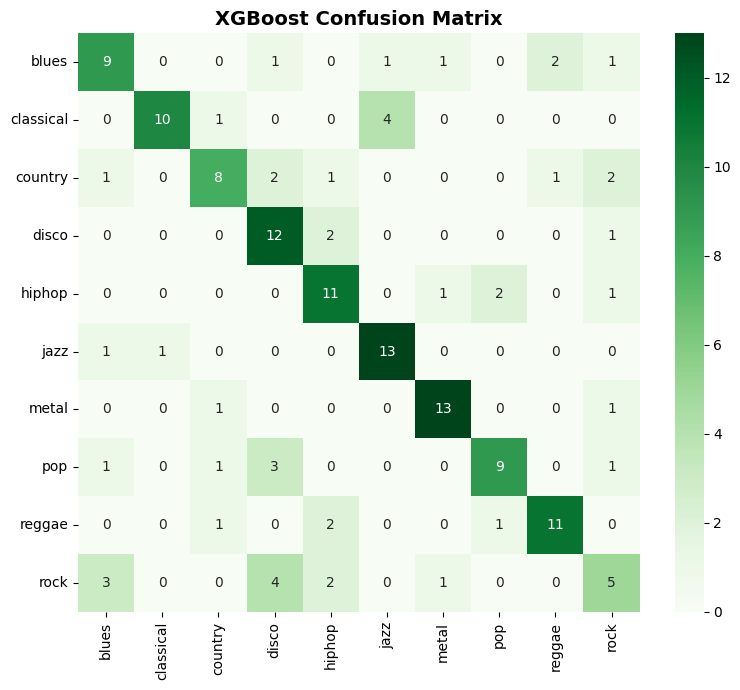

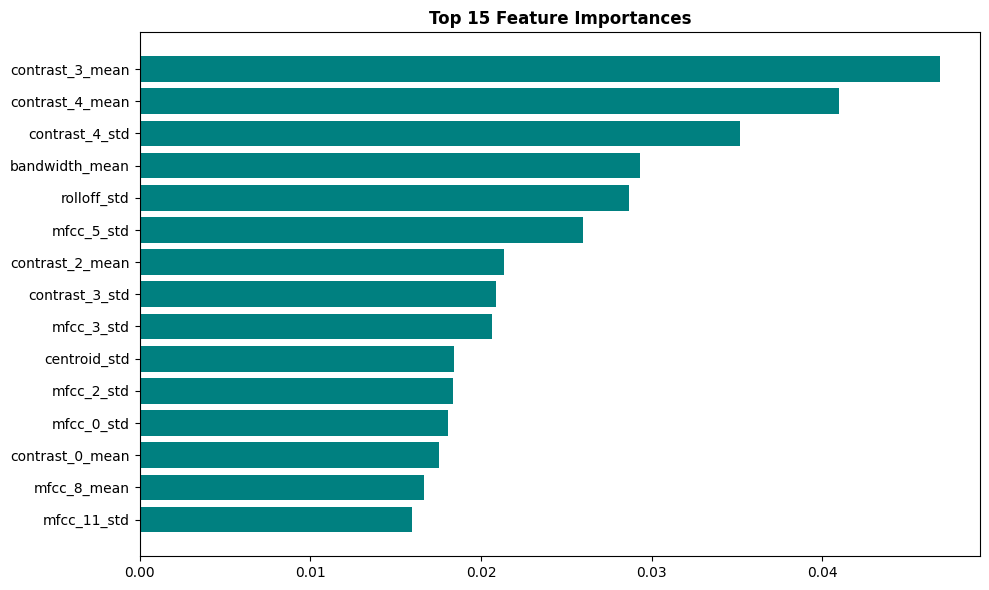

wandb: updating run metadata
wandb: uploading history steps 0-0, summary, console lines 0-27
wandb: 
wandb: Run history:
wandb: xgb_val_acc ▁
wandb:  xgb_val_f1 ▁
wandb: 
wandb: Run summary:
wandb: xgb_val_acc 0.67333
wandb:  xgb_val_f1 0.66994
wandb: 
wandb: 🚀 View run xgboost-handcrafted at: https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026/runs/1r4empu4
wandb: ⭐️ View project at: https://wandb.ai/24f1001544-dl-genai-project/24f1001544-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260327_184601-1r4empu4/logs


XGBoost run finished!


In [30]:
# -- 4.2  XGBoost Training ---
from sklearn.model_selection import train_test_split as tts
X_tr, X_va, y_tr, y_va = tts(X_all, y_all, test_size=0.15, random_state=SEED, stratify=y_all)

xgb_model = XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, objective='multi:softmax', num_class=10,
    random_state=SEED, use_label_encoder=False, eval_metric='mlogloss', tree_method='hist')

run_xgb = wandb.init(project='24f1001544-t12026', name='xgboost-handcrafted',
    config={'model': 'XGBoost', 'n_estimators': 500, 'max_depth': 8, 'features': X_all.shape[1]},
    settings=wandb.Settings(start_method='thread'), reinit=True)

xgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=50)
xgb_preds = xgb_model.predict(X_va)
xgb_f1 = f1_score(y_va, xgb_preds, average='macro')
xgb_acc = accuracy_score(y_va, xgb_preds)

print(f'XGBoost Val F1: {xgb_f1:.4f} | Acc: {xgb_acc:.4f}')
print(classification_report(y_va, xgb_preds, target_names=GENRES, digits=4))

cm_xgb = confusion_matrix(y_va, xgb_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=GENRES, yticklabels=GENRES, ax=ax)
ax.set_title('XGBoost Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(str(OUT_DIR / 'xgb_confusion_matrix.png'), dpi=120); plt.show()

fi = xgb_model.feature_importances_
feat_names = ([f'mfcc_{i}_mean' for i in range(13)] + [f'mfcc_{i}_std' for i in range(13)]
              + [f'chroma_{i}_mean' for i in range(12)] + [f'chroma_{i}_std' for i in range(12)]
              + [f'contrast_{i}_mean' for i in range(7)] + [f'contrast_{i}_std' for i in range(7)]
              + ['zcr_mean','zcr_std','centroid_mean','centroid_std',
                 'bandwidth_mean','bandwidth_std','rolloff_mean','rolloff_std'])
top_idx = np.argsort(fi)[-15:]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([feat_names[i] for i in top_idx], fi[top_idx], color='teal')
ax.set_title('Top 15 Feature Importances', fontweight='bold')
plt.tight_layout(); plt.savefig(str(OUT_DIR / 'xgb_feature_importance.png'), dpi=120); plt.show()

wandb.log({'xgb_val_f1': xgb_f1, 'xgb_val_acc': xgb_acc})
wandb.finish()
print('XGBoost run finished!')

---
# Section 5: Model Comparison

Comparing all three models on common metrics: **Macro F1** and **Accuracy**.

       FINAL MODEL COMPARISON
              Model           Type   Val_F1  Val_Acc
     CRNN (Scratch)   From Scratch 0.591402 0.606667
AST v3 (Pretrained)     Pretrained 0.946496 0.946667
       XGBoost (ML) Traditional ML 0.669938 0.673333


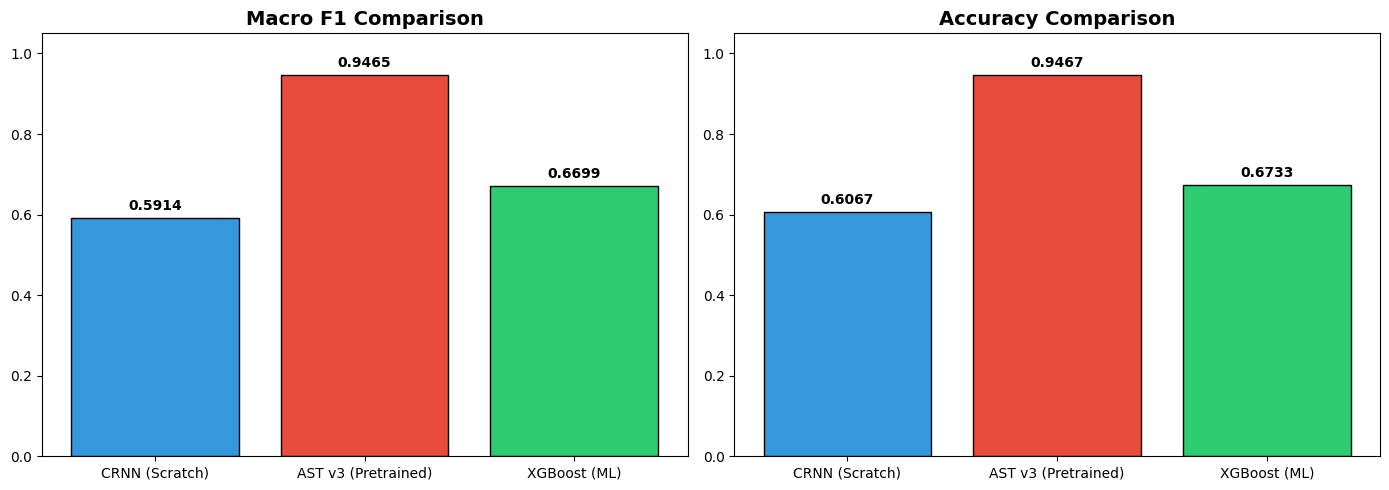

All 3 models trained, evaluated, and compared!


In [31]:
# -- 5.1  Final Comparison ---
results = pd.DataFrame({
    'Model':   ['CRNN (Scratch)', 'AST v3 (Pretrained)', 'XGBoost (ML)'],
    'Type':    ['From Scratch',   'Pretrained',           'Traditional ML'],
    'Val_F1':  [crnn_final_f1,    adj_f1,                 xgb_f1],
    'Val_Acc': [crnn_final_acc,   accuracy_score(all_labels, adj_preds), xgb_acc],
})

print('=' * 60)
print('       FINAL MODEL COMPARISON')
print('=' * 60)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']
axes[0].bar(results['Model'], results['Val_F1'], color=colors, edgecolor='black')
axes[0].set_title('Macro F1 Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(results['Val_F1']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].bar(results['Model'], results['Val_Acc'], color=colors, edgecolor='black')
axes[1].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(results['Val_Acc']):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'model_comparison.png'), dpi=120)
plt.show()
print('All 3 models trained, evaluated, and compared!')

---
## Conclusions

1. **AST v3 (Pretrained Transformer)** achieves the highest F1 by leveraging pre-trained AudioSet
   knowledge combined with domain-specific augmentations (cross-track mixing, tempo aug, noise).
2. **CRNN (From Scratch)** provides a solid baseline using CNN+RNN on Mel-spectrograms.
3. **XGBoost (Traditional ML)** shows handcrafted features capture meaningful genre information,
   but cannot match the representation learning of deep models.

> Key Takeaway: Pre-trained transformers with domain-aware augmentation significantly outperform
> both from-scratch DL and traditional ML for audio classification tasks.